In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"F:\\data sets\\house_price - house_price.csv")
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [5]:
df.shape

(2930, 82)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-null   object 
 17  House Style   

# Data Cleaning

#### checking the null values

In [11]:
columns = list(df.columns)
null_clo = []
for i in columns:
    if df[i].isnull().sum() != 0:
        print(i,'->',df[i].isnull().sum())
        null_clo.append(i)

Lot Frontage -> 490
Alley -> 2732
Mas Vnr Type -> 1775
Mas Vnr Area -> 23
Bsmt Qual -> 80
Bsmt Cond -> 80
Bsmt Exposure -> 83
BsmtFin Type 1 -> 80
BsmtFin SF 1 -> 1
BsmtFin Type 2 -> 81
BsmtFin SF 2 -> 1
Bsmt Unf SF -> 1
Total Bsmt SF -> 1
Electrical -> 1
Bsmt Full Bath -> 2
Bsmt Half Bath -> 2
Fireplace Qu -> 1422
Garage Type -> 157
Garage Yr Blt -> 159
Garage Finish -> 159
Garage Cars -> 1
Garage Area -> 1
Garage Qual -> 159
Garage Cond -> 159
Pool QC -> 2917
Fence -> 2358
Misc Feature -> 2824


###### Pool QC -> 2917
###### Fence -> 2358
###### Misc Feature -> 2824
###### These column nearly has 90% null values so i am droping these columnns

In [14]:
df.drop(columns = ['Pool QC','Fence','Misc Feature'],inplace=True)
df.shape

(2930, 79)

In [16]:
df.drop(columns=['Fireplace Qu','Mas Vnr Type','Alley'], inplace=True)

In [18]:
# Removed null values with ffill() method
col=['BsmtFin SF 1','BsmtFin SF 2','Bsmt Unf SF','Total Bsmt SF','Electrical','Bsmt Full Bath','Bsmt Half Bath','Garage Cars',
'Garage Area' ]
for i in col:
    df[i]=df[i].ffill()
    print(i,'->',df[i].isnull().sum())

BsmtFin SF 1 -> 0
BsmtFin SF 2 -> 0
Bsmt Unf SF -> 0
Total Bsmt SF -> 0
Electrical -> 0
Bsmt Full Bath -> 0
Bsmt Half Bath -> 0
Garage Cars -> 0
Garage Area -> 0


#### Replaced integer column null values with the mean of respective column


In [21]:
# Replaced integer column null values with the mean of respective column
int_col = list(df.select_dtypes(include='int').columns)
#int_col
for i in int_col:
    df[i]=df[i].fillna(df[i].mean())
    print(i,'->',df[i].isnull().sum())

Order -> 0
PID -> 0
MS SubClass -> 0
Lot Area -> 0
Overall Qual -> 0
Overall Cond -> 0
Year Built -> 0
Year Remod/Add -> 0
1st Flr SF -> 0
2nd Flr SF -> 0
Low Qual Fin SF -> 0
Gr Liv Area -> 0
Full Bath -> 0
Half Bath -> 0
Bedroom AbvGr -> 0
Kitchen AbvGr -> 0
TotRms AbvGrd -> 0
Fireplaces -> 0
Wood Deck SF -> 0
Open Porch SF -> 0
Enclosed Porch -> 0
3Ssn Porch -> 0
Screen Porch -> 0
Pool Area -> 0
Misc Val -> 0
Mo Sold -> 0
Yr Sold -> 0
SalePrice -> 0


#### Replaced float column null values with the mean of respective column


In [24]:
float_col = list(df.select_dtypes(include='float').columns)
#float_col
for i in float_col:
    df[i]=df[i].fillna(df[i].mean())
    print(i,'->',df[i].isnull().sum())

Lot Frontage -> 0
Mas Vnr Area -> 0
BsmtFin SF 1 -> 0
BsmtFin SF 2 -> 0
Bsmt Unf SF -> 0
Total Bsmt SF -> 0
Bsmt Full Bath -> 0
Bsmt Half Bath -> 0
Garage Yr Blt -> 0
Garage Cars -> 0
Garage Area -> 0


In [26]:
columns = list(df.columns)
remaning_null = []
for i in columns:
    if df[i].isnull().sum() != 0:
        print(i,'->',df[i].isnull().sum())
        remaning_null.append(i)

Bsmt Qual -> 80
Bsmt Cond -> 80
Bsmt Exposure -> 83
BsmtFin Type 1 -> 80
BsmtFin Type 2 -> 81
Garage Type -> 157
Garage Finish -> 159
Garage Qual -> 159
Garage Cond -> 159


#### Replaced object datatype column null values with the mode of respective column


In [29]:
df[['Bsmt Qual','Bsmt Cond','Bsmt Exposure','BsmtFin Type 1', 'BsmtFin Type 2', 'Garage Type', 'Garage Finish', 'Garage Qual', 
'Garage Cond', 
]]

,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Garage Type,Garage Finish,Garage Qual,Garage Cond
0,TA,Gd,Gd,BLQ,Unf,Attchd,Fin,TA,TA
1,TA,TA,No,Rec,LwQ,Attchd,Unf,TA,TA
2,TA,TA,No,ALQ,Unf,Attchd,Unf,TA,TA
3,TA,TA,No,ALQ,Unf,Attchd,Fin,TA,TA
4,Gd,TA,No,GLQ,Unf,Attchd,Fin,TA,TA
...,...,...,...,...,...,...,...,...,...
2925,TA,TA,Av,GLQ,Unf,Detchd,Unf,TA,TA
2926,Gd,TA,Av,BLQ,ALQ,Attchd,Unf,TA,TA
2927,Gd,TA,Av,GLQ,Unf,NaN,NaN,NaN,NaN
2928,Gd,TA,Av,ALQ,LwQ,Attchd,RFn,TA,TA


In [31]:
for i in remaning_null:
    df[i]=df[i].fillna(df[i].mode()[0])
    print(i,'->',df[i].isnull().sum())


Bsmt Qual -> 0
Bsmt Cond -> 0
Bsmt Exposure -> 0
BsmtFin Type 1 -> 0
BsmtFin Type 2 -> 0
Garage Type -> 0
Garage Finish -> 0
Garage Qual -> 0
Garage Cond -> 0


In [33]:
df.isnull().sum()

Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 76, dtype: int64

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 76 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2930 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Lot Shape        2930 non-null   object 
 8   Land Contour     2930 non-null   object 
 9   Utilities        2930 non-null   object 
 10  Lot Config       2930 non-null   object 
 11  Land Slope       2930 non-null   object 
 12  Neighborhood     2930 non-null   object 
 13  Condition 1      2930 non-null   object 
 14  Condition 2      2930 non-null   object 
 15  Bldg Type        2930 non-null   object 
 16  House Style      2930 non-null   object 
 17  Overall Qual  

In [37]:
df.shape

(2930, 76)

# Handling Duplicate data

In [40]:
df.duplicated().sum()

0

In [42]:
df[df.duplicated()]

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice


##### There are no duplicate values to handel

# Cleaned Dataset

In [46]:
df

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.00000,31770,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.00000,11622,Pave,Reg,Lvl,AllPub,...,0,0,120,0,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.00000,14267,Pave,IR1,Lvl,AllPub,...,0,0,0,0,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.00000,11160,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.00000,13830,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2010,WD,Normal,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,2926,923275080,80,RL,37.00000,7937,Pave,IR1,Lvl,AllPub,...,0,0,0,0,0,3,2006,WD,Normal,142500
2926,2927,923276100,20,RL,69.22459,8885,Pave,IR1,Low,AllPub,...,0,0,0,0,0,6,2006,WD,Normal,131000
2927,2928,923400125,85,RL,62.00000,10441,Pave,Reg,Lvl,AllPub,...,0,0,0,0,700,7,2006,WD,Normal,132000
2928,2929,924100070,20,RL,77.00000,10010,Pave,Reg,Lvl,AllPub,...,0,0,0,0,0,4,2006,WD,Normal,170000


In [48]:
df.describe().round()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.0,2.930000e+03,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,...,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0,2930.0
mean,1466.0,7.144645e+08,57.0,69.0,10148.0,6.0,6.0,1971.0,1984.0,102.0,...,94.0,48.0,23.0,3.0,16.0,2.0,51.0,6.0,2008.0,180796.0
std,846.0,1.887308e+08,43.0,21.0,7880.0,1.0,1.0,30.0,21.0,178.0,...,126.0,67.0,64.0,25.0,56.0,36.0,566.0,3.0,1.0,79887.0
min,1.0,5.263011e+08,20.0,21.0,1300.0,1.0,1.0,1872.0,1950.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2006.0,12789.0
25%,733.0,5.284770e+08,20.0,60.0,7440.0,5.0,5.0,1954.0,1965.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,2007.0,129500.0
50%,1466.0,5.354536e+08,50.0,69.0,9436.0,6.0,5.0,1973.0,1993.0,0.0,...,0.0,27.0,0.0,0.0,0.0,0.0,0.0,6.0,2008.0,160000.0
75%,2198.0,9.071811e+08,70.0,78.0,11555.0,7.0,6.0,2001.0,2004.0,163.0,...,168.0,70.0,0.0,0.0,0.0,0.0,0.0,8.0,2009.0,213500.0
max,2930.0,1.007100e+09,190.0,313.0,215245.0,10.0,9.0,2010.0,2010.0,1600.0,...,1424.0,742.0,1012.0,508.0,576.0,800.0,17000.0,12.0,2010.0,755000.0


# Outlier detection

In [51]:
num_cols = df.select_dtypes(include='number').columns
num_cols

Index(['Order', 'PID', 'MS SubClass', 'Lot Frontage', 'Lot Area',
       'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add',
       'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF',
       'Total Bsmt SF', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF',
       'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath',
       'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'TotRms AbvGrd',
       'Fireplaces', 'Garage Yr Blt', 'Garage Cars', 'Garage Area',
       'Wood Deck SF', 'Open Porch SF', 'Enclosed Porch', '3Ssn Porch',
       'Screen Porch', 'Pool Area', 'Misc Val', 'Mo Sold', 'Yr Sold',
       'SalePrice'],
      dtype='object')

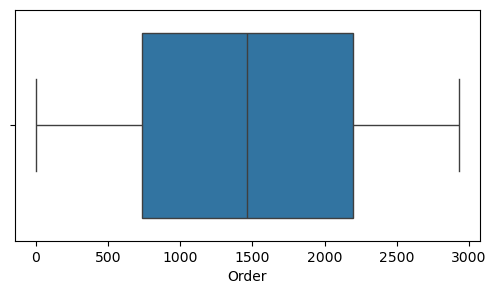

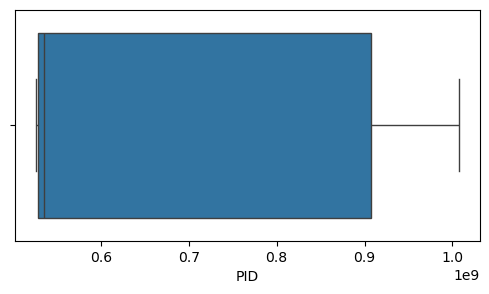

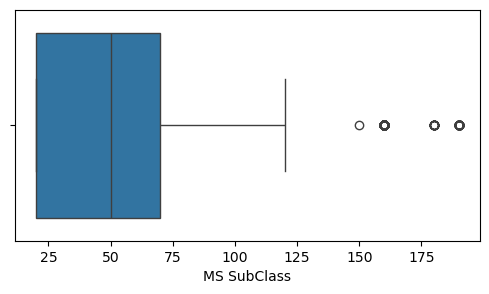

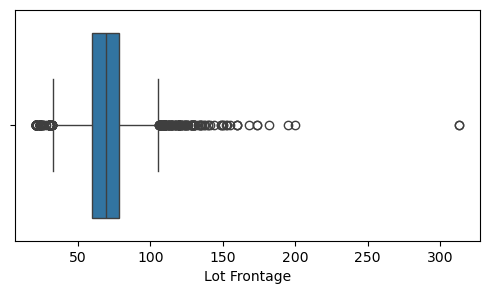

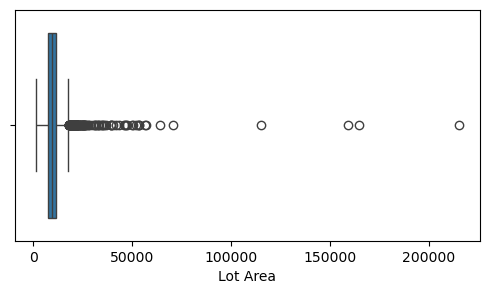

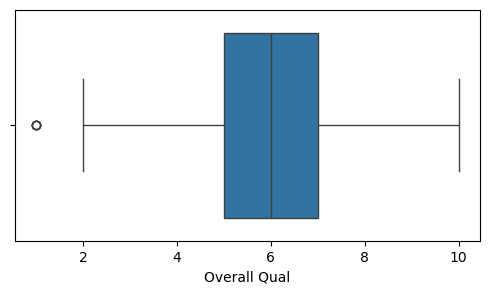

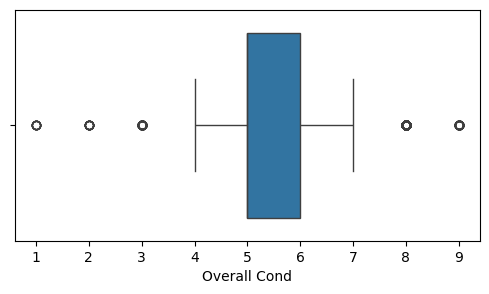

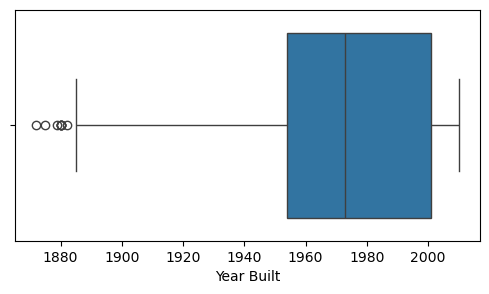

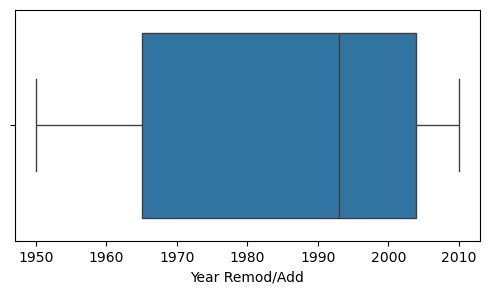

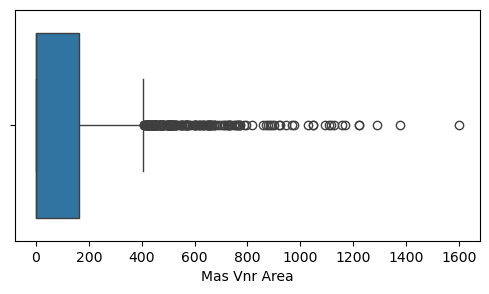

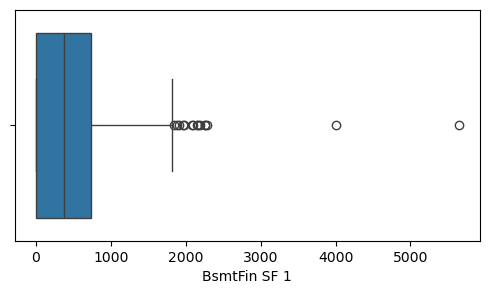

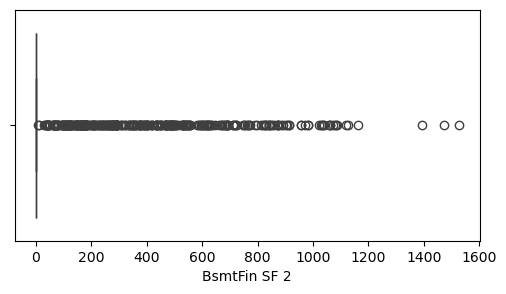

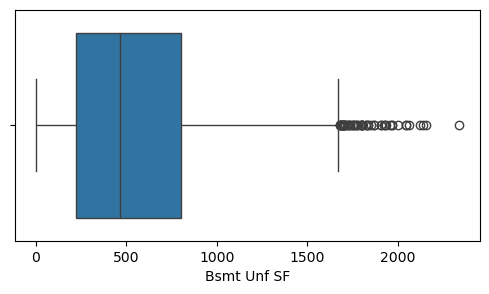

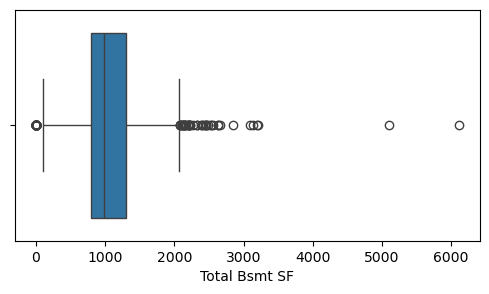

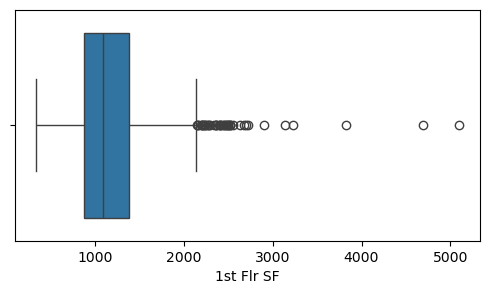

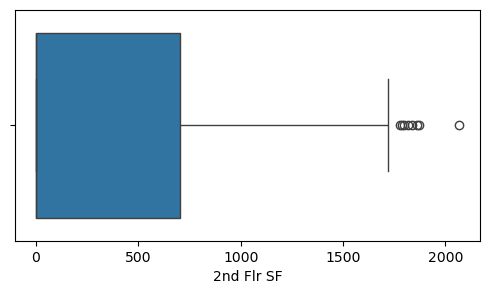

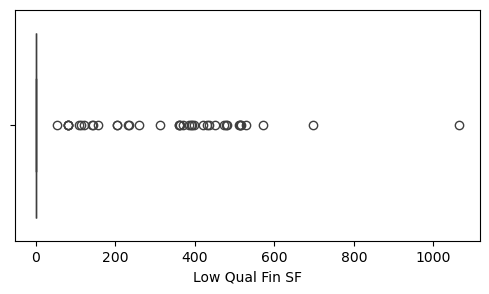

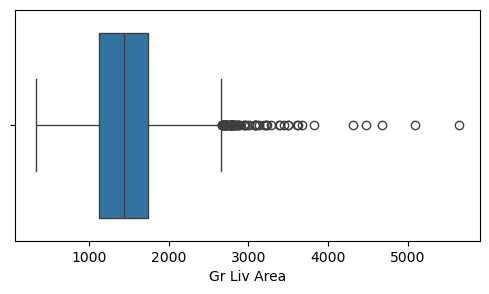

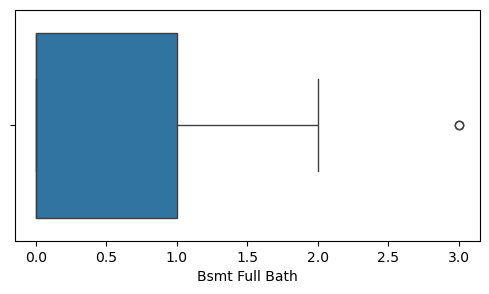

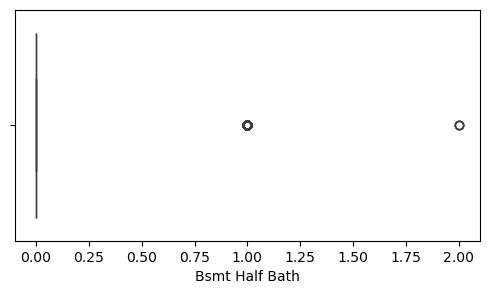

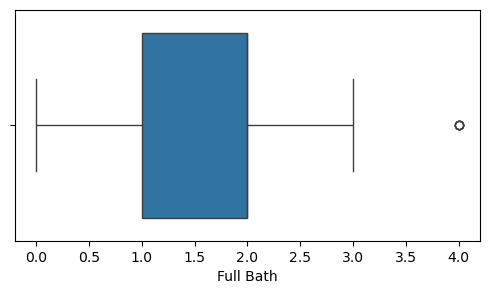

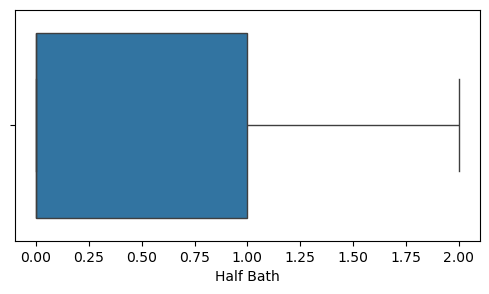

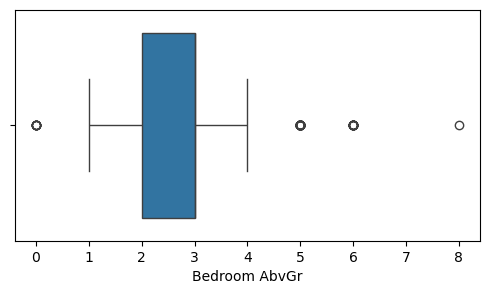

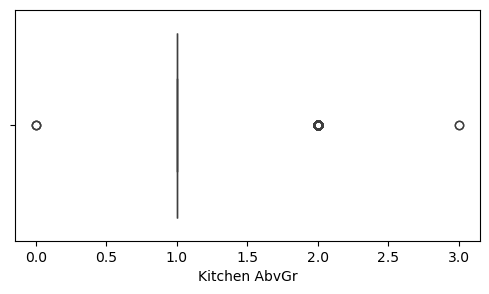

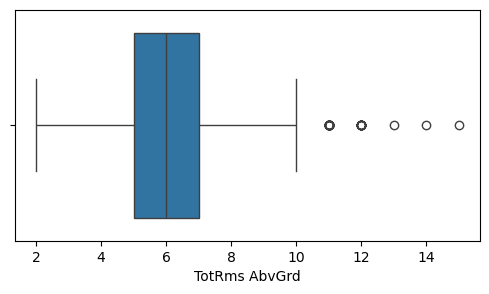

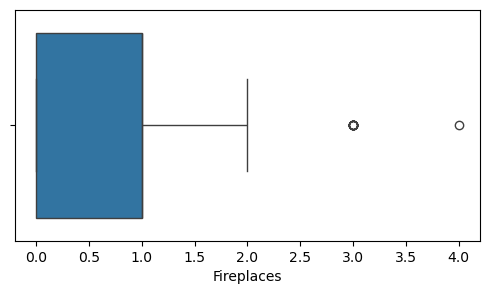

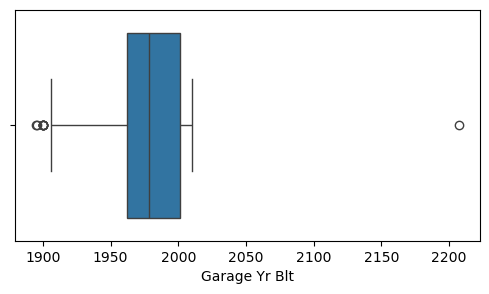

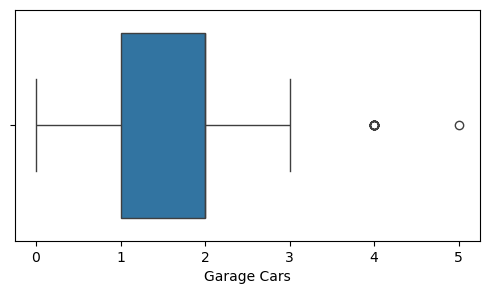

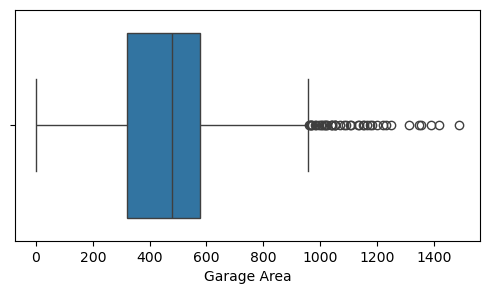

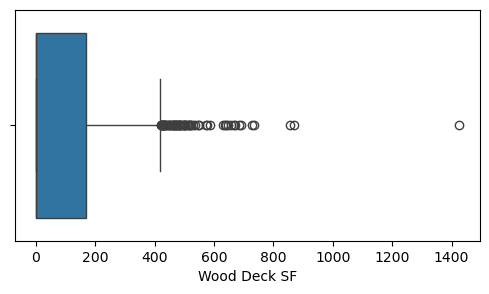

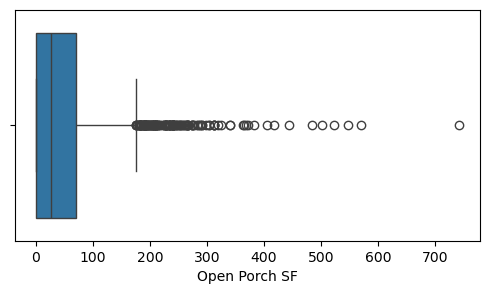

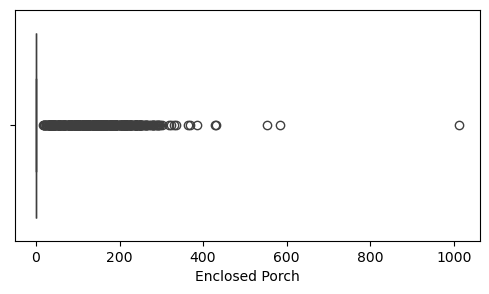

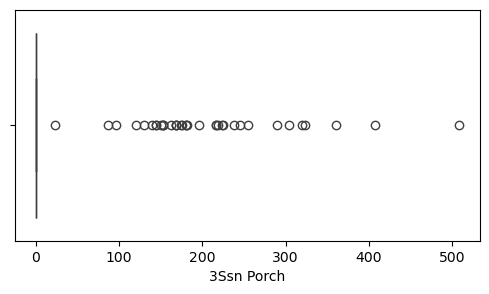

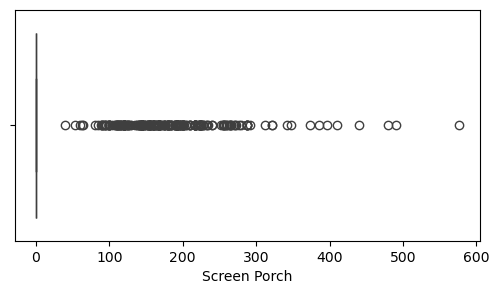

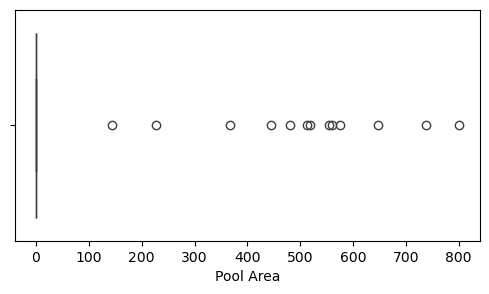

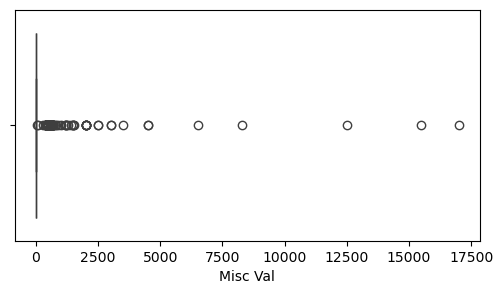

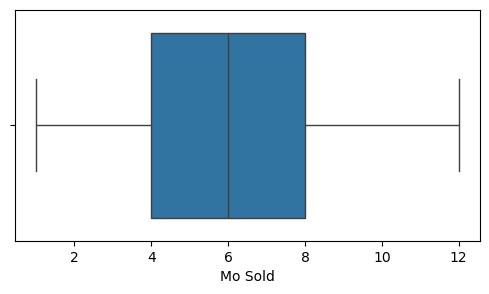

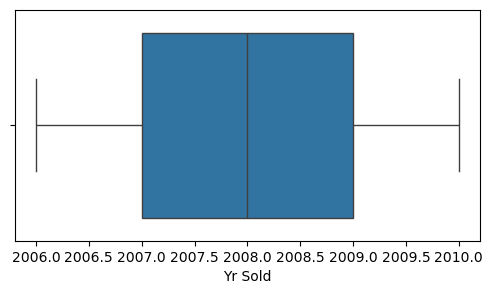

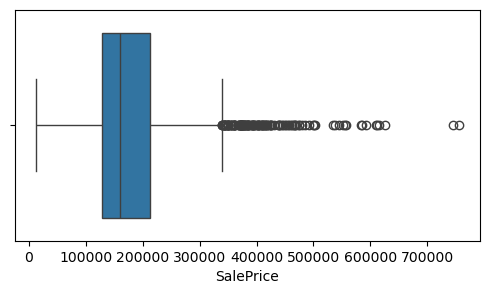

In [53]:
for i in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[i])
    plt.show()

In [54]:
# Replaced outliers with the lower and upper bound
num_cols = df.select_dtypes(include='number').columns
for i in num_cols:
    Q1 = df[i].quantile(0.25)
    Q3 = df[i].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1-1.5*IQR
    upper = Q3+1.5*IQR
    df[i] = df[i].clip(lower,upper)

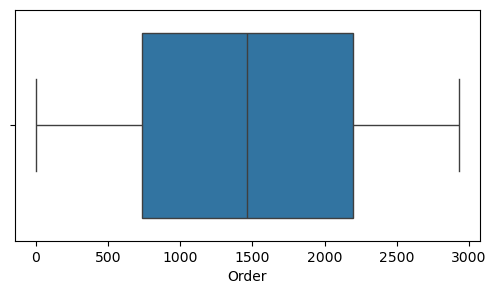

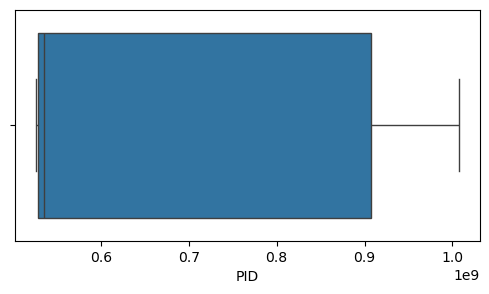

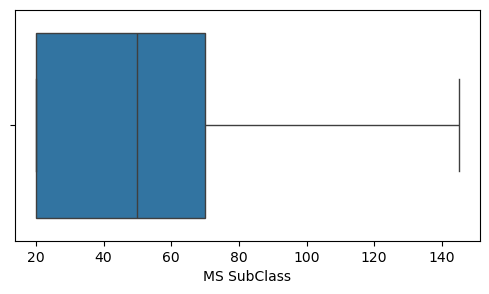

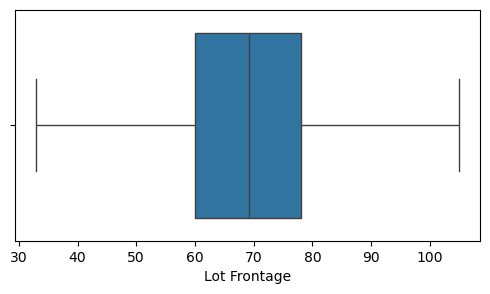

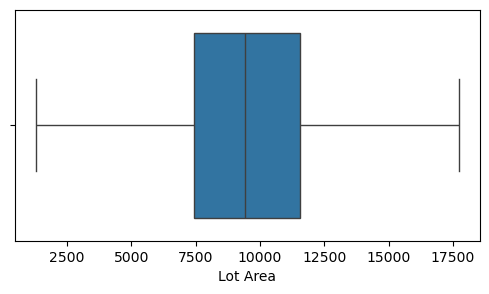

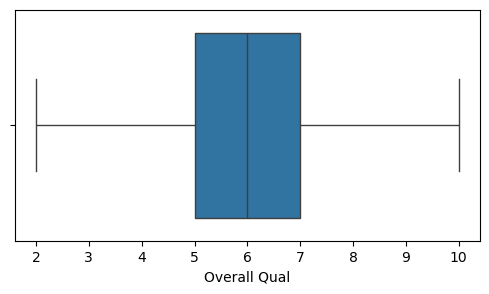

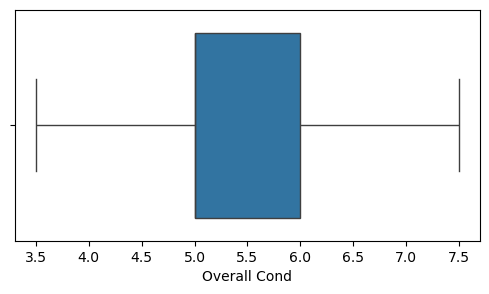

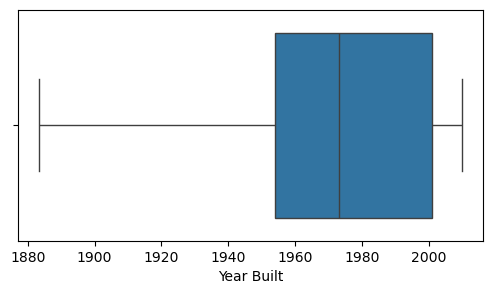

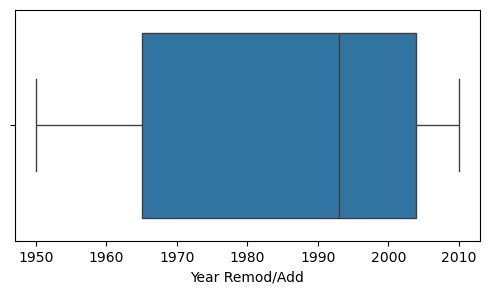

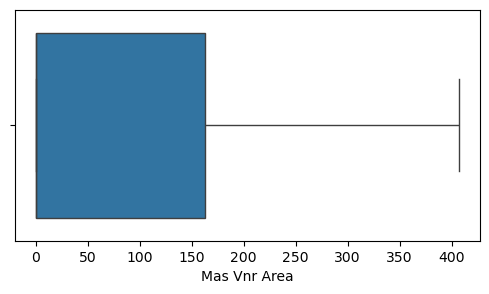

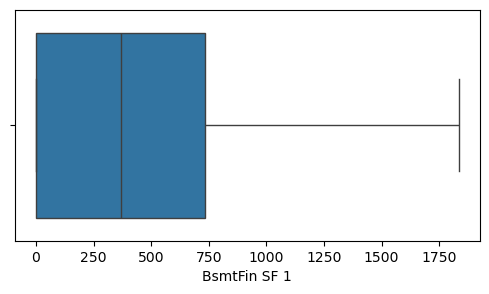

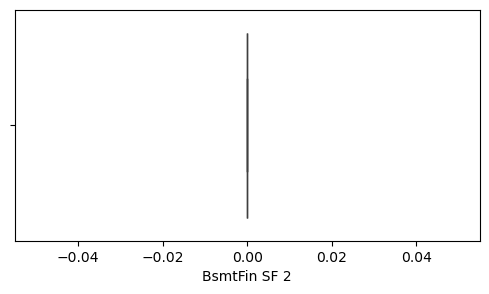

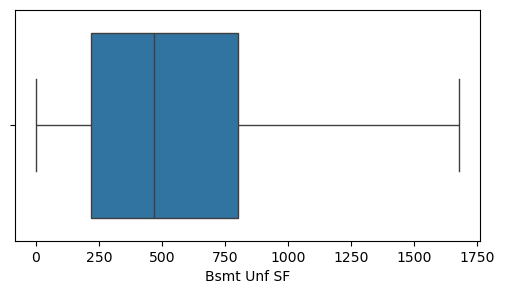

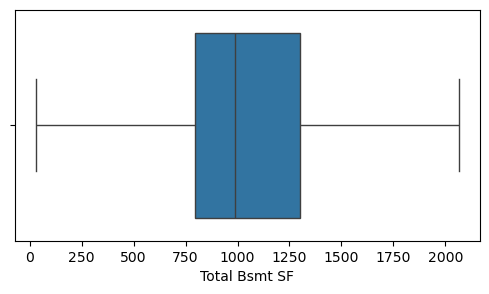

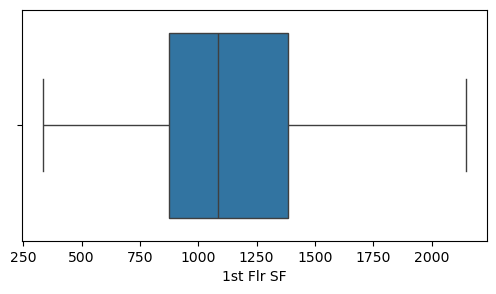

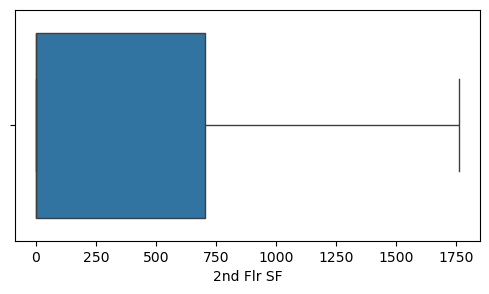

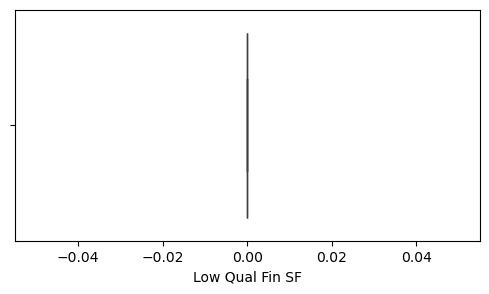

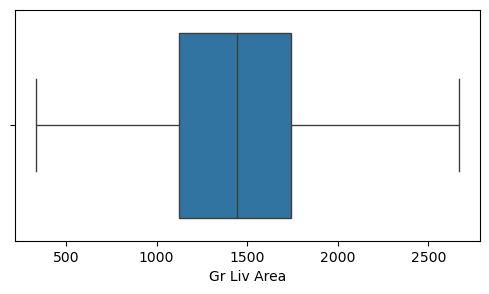

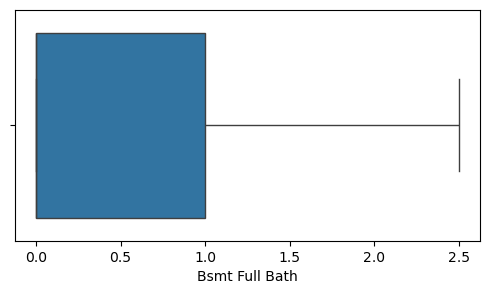

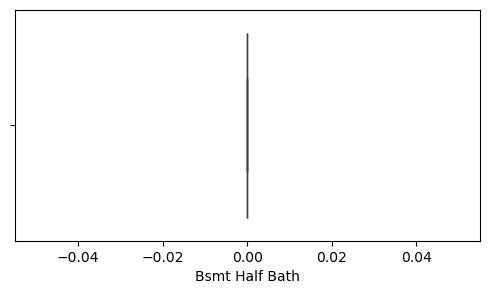

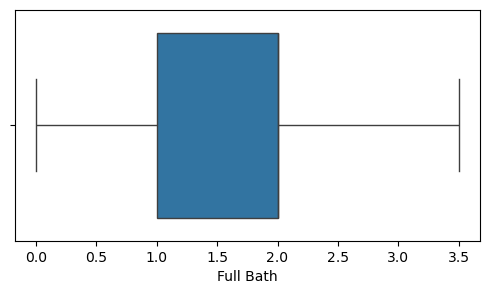

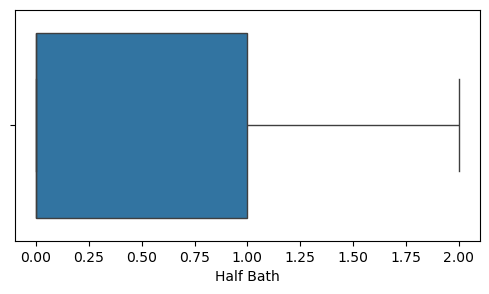

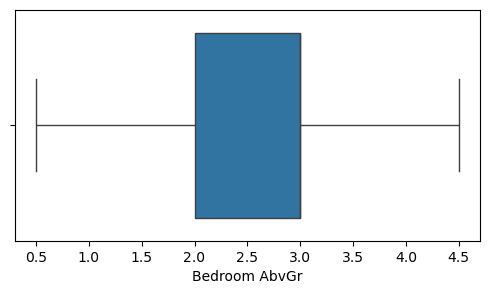

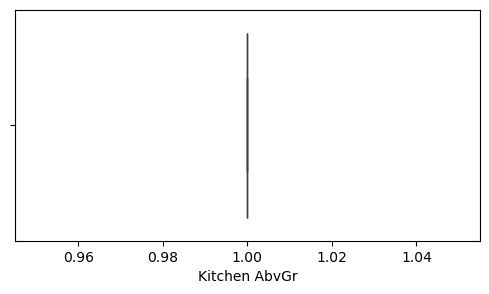

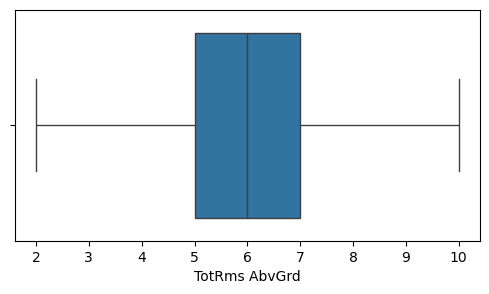

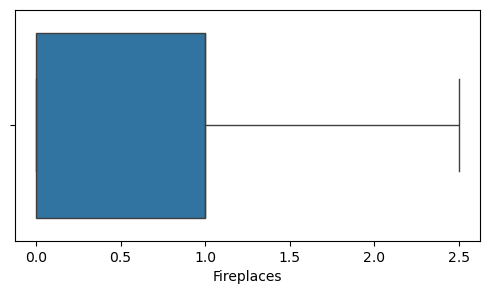

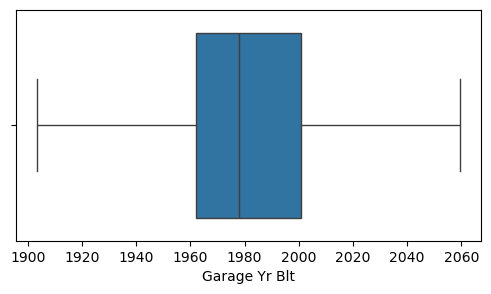

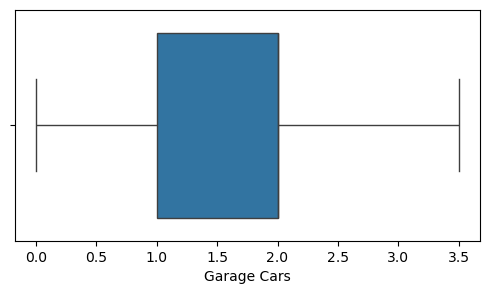

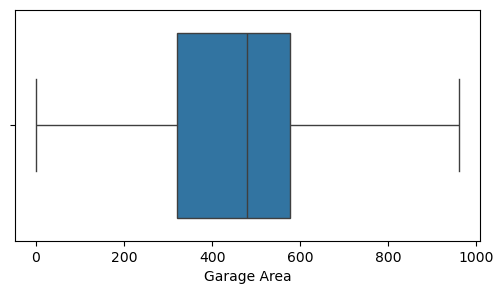

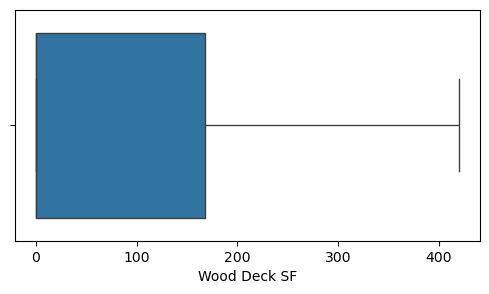

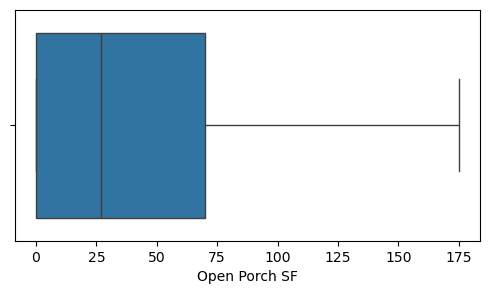

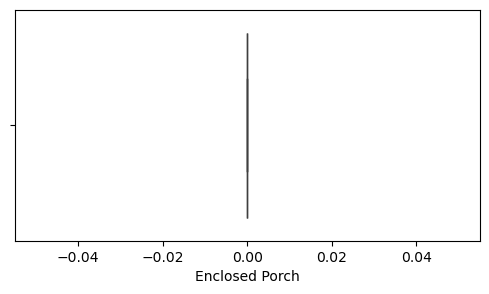

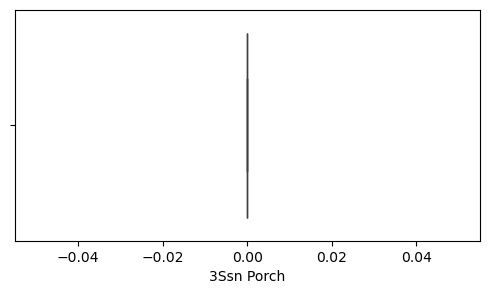

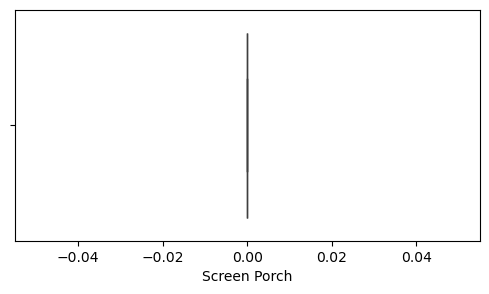

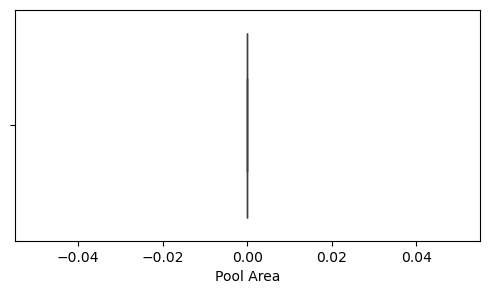

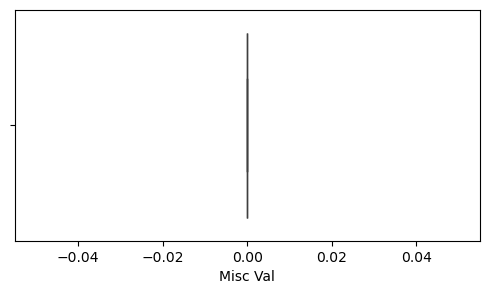

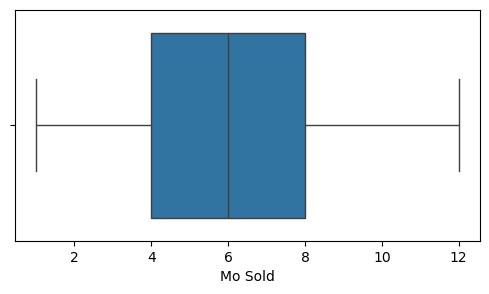

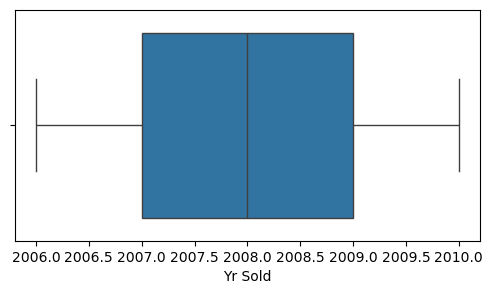

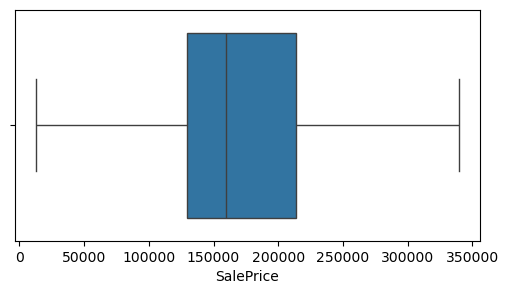

In [55]:
for i in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[i])
    plt.show()

<Axes: xlabel='SalePrice', ylabel='Lot Area'>

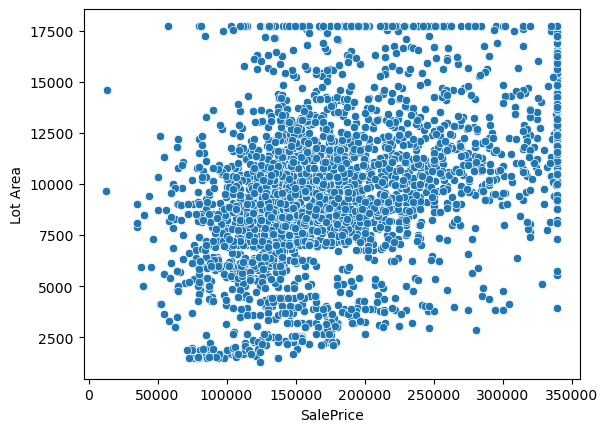

In [56]:
# Scatter plot for area vs price
sns.scatterplot(x='SalePrice',y='Lot Area',data=df)

In [63]:
df.drop(columns=['Order','PID'],inplace=True)

#### Encoding categorical features(Location,type)


In [66]:
str_col = df.select_dtypes(include='object').columns
str_col

# Encoding categorical features(Location,type)
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for i in str_col:
    df[i] = encoder.fit_transform(df[i])




In [67]:
df

,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,20,5,105.00000,17727.75,1,0,3,0,0,0,...,0,0,0,0,0,5,2010,9,4,215000
1,20,4,80.00000,11622.00,1,3,3,0,4,0,...,0,0,0,0,0,6,2010,9,4,105000
2,20,5,81.00000,14267.00,1,0,3,0,0,0,...,0,0,0,0,0,6,2010,9,4,172000
3,20,5,93.00000,11160.00,1,3,3,0,0,0,...,0,0,0,0,0,4,2010,9,4,244000
4,60,5,74.00000,13830.00,1,0,3,0,4,0,...,0,0,0,0,0,3,2010,9,4,189900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2925,80,5,37.00000,7937.00,1,0,3,0,1,0,...,0,0,0,0,0,3,2006,9,4,142500
2926,20,5,69.22459,8885.00,1,0,2,0,4,1,...,0,0,0,0,0,6,2006,9,4,131000
2927,85,5,62.00000,10441.00,1,3,3,0,4,0,...,0,0,0,0,0,7,2006,9,4,132000
2928,20,5,77.00000,10010.00,1,3,3,0,4,1,...,0,0,0,0,0,4,2006,9,4,170000


In [70]:
X = df.iloc[:,0:72].values
y=df.iloc[:,-1].values

In [72]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25)

### Feature Scaling

In [75]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### LinearRegression

In [78]:
from sklearn.linear_model import LinearRegression
reg = LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [80]:
y_pred = reg.predict(X_test)
y_pred

array([152568.2832345 , 230739.55647194, 246325.80296065, 144250.06289668,
       133864.77216569, 231969.3010649 , 109834.15221702, 183907.59910747,
       111514.9435234 ,  60849.4990736 , 131537.52357404, 225989.44211469,
       215732.29943382,  79924.79303604, 102040.21833139, 131217.51662096,
       154735.02296091, 181710.68253731, 123754.57746357, 336915.05819647,
       253997.65280106, 107416.30443435, 275839.42474043, 124252.41269868,
       184865.61814823, 251187.0901194 , 157726.46935249, 270198.01229087,
       156379.54803204, 294525.71324196, 311363.75959458, 138870.20887313,
       126898.59526314, 151571.14434061, 131658.79125147,  55728.64409765,
       116098.73804866, 258469.43647245, 147965.20744585, 115388.9290195 ,
       109306.61967116, 164270.50538211, 252784.93158342, 171167.04219609,
       262848.92826321, 118656.45870409, 177770.12715091, 163032.83327853,
       288047.15050698,  69491.01121121, 104297.93476843, 183830.43737728,
        55848.03566573, 2

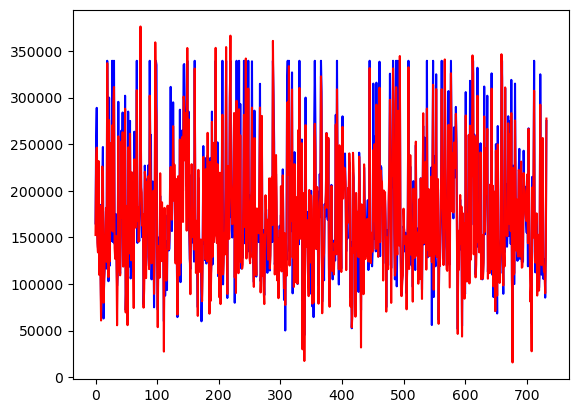

In [82]:
plt.plot(y_test,color='blue',label='Test')
plt.plot(y_pred,color='red',label='Prediction')
plt.show()

ValueError: 'color' kwarg must be a color or sequence of color specs.  For a sequence of values to be color-mapped, use the 'c' argument instead.

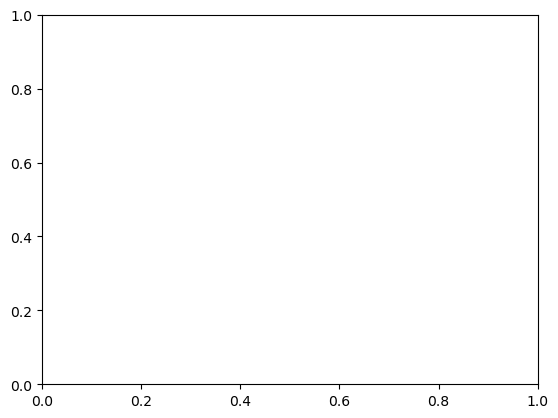

In [92]:
plt.scatter(y_test,y_pred,color='blue,red')


In [84]:
import numpy as np
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
print('R2 Score: ',r2_score(y_test,y_pred))
print('MAE: ',mean_absolute_error(y_test,y_pred))

print('RMSE: ',np.sqrt(mean_squared_error(y_test,y_pred)))

R2 Score:  0.9213771528307929
MAE:  15147.556376227036
RMSE:  19944.28429273191


In [86]:
data = [[20,5,81.0,14267.0,1,0,3,0,0,0,15,2,2,0,2,6,6.0,1958.0,1958,5,1,14,15,108.0,3,10,1,4,4,3,0,923.0,5,0.0,406.0,1329.0,1,4,1,4,1329.0,0.0,0,1329.0,0.0,0.0,1.0,1,3.0,1,2,6,7,0.0,1,1958.0,2,1.0,312.0,4,4,2,393,36,0,0,0,0,0,6,2010,9]]
new_df = pd.DataFrame(data)
new_val = scaler.transform(new_df)
predicted_value = reg.predict(new_val)
print(predicted_value.round())

[169142.]


# Decision Tree

In [93]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier()
DT.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [95]:
y_pred = DT.predict(X_test)

In [97]:
from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
confusion_matrix  = confusion_matrix(y_test, y_pred)
print(accuracy)
print(confusion_matrix)

0.040927694406548434
[[ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  0  0]
 ...
 [ 0  0  0 ...  0  0  1]
 [ 0  0  0 ...  0  0  0]
 [ 0  0  0 ...  0  1 23]]


In [99]:
from sklearn.ensemble import RandomForestClassifier

# initiate the classifier
model_rf = RandomForestClassifier()

# Passing the data to classifier
model_rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [100]:
y_pred_rf = model_rf.predict(X_test)

In [106]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred_rf))

0.06002728512960437
